# Strategic Forecasting of the S&P 500: A Hybrid SARIMA-GARCH Approach
### Advanced Econometric Modeling with Exogenous Macro-Dynamics

**Author:** Adrián Aruya Tanarro Musa

**Role:** Quantitative Research & Financial Modeling

**Date:** From March 2026

# Executive Introduction

---

This notebook develops and validates a high-precision forecasting engine for the S&P 500 (SPX). By moving beyond simple trend analysis, this project integrates the structural memory of time-series with the conditional volatility of financial markets.

### The Objective
The core goal is to outperform a Random Walk (Naive) Benchmark by predicting 1-day ahead returns using a combination of internal price history and external macroeconomic "shocks."

### The Model Architecture: SARIMA(1,0,1) + GARCH(1,1)

The strategy is built on two mathematical pillars:

1. **SARIMA(1,0,1):** Captures the "Autoregressive" memory (up to 1 day) and "Moving Average" shocks, adjusted for seasonality and long-term trends.
   
2. **GARCH(1,1):** Specifically addresses Volatility Clustering, ensuring that our risk intervals expand during periods of market stress.

3. **Exogenous Regressors ($X$):** The model is "fed" with real-time data from:
    * **DXY (US Dollar Index):** Measuring global liquidity.
    * **VIX (Volatility Index):** Capturing institutional "fear."
    * **10Y Treasury Yields:** Reflecting inflation expectations.

### Key Performance Indicators (KPIs)
* **Directional Accuracy (Hit Rate):** ≈ 56.67%
* **MAE Improvement:** 2.19% reduction in error vs. Random Walk ( 46.63 vs 45.62 ).
* **Validation Method:** Unbiased Out-of-Sample Walk-Forward Backtest over a 60-business-day horizon.

---

# Methodology & Technical Framework

This section outlines the econometric "engine" and the computational tools used to achieve the **56.67% Hit Rate**. 

### The Libraries (Tech Stack)
We utilize a specialized Python stack designed for high-frequency financial econometrics:

* **`Pandas` & `NumPy`:** For vectorized data manipulation and log-return calculations.

* **`Statsmodels (SARIMAX)`:** To model the conditional mean (price direction) and handle exogenous macro-regressors.

* **`ARCH`:** To estimate the conditional variance (GARCH) and manage non-normal "fat-tailed" distributions.

* **`Matplotlib`:** For high-fidelity financial visualization and fan-chart generation.

### Data Sources
We used two main sources for the data of the variables:

* *Yahoo finance*

* *FRED (Federal Reserve Economic Data)*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ta 
import yfinance as yf
from fredapi import Fred 
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from ta.momentum import RSIIndicator
from statsmodels.tsa.statespace.sarimax import SARIMAX

### The Modeling Logic
The project follows a three-stage modeling forecasting process:

1.  **Stationarity Transformation:** Raw prices are converted to *Log-Returns* to ensure a constant mean and variance, a prerequisite for stable SARIMA or any other econometric estimation.

2.  **Exogenous Integration:** We don't just look at the S&P 500 in isolation. We inject *DXY (USD Index)*, *VIX (Fear Index)*, and *10Y Yields* as leading indicators to provide the model with "context" regarding global liquidity and risk sentiment. At first, we also included the *RSI (Strengh of the Market)* and *Gold (market stability)* as variables, but as our procedure continues we left them out as a consequence of multicolinearity with other variables and autocorrelation.

3.  **"Cleaning" our Model:** We create our model and make changes so that the model adheres to the assumptions.
   
---

In [2]:
start_date = "2019-01-01"
end_date   = "2026-06-05"

In [3]:
sp500 = yf.Ticker("^GSPC")
df_sp500 = sp500.history(start=start_date, end=end_date)["Close"]

In [4]:
gold = yf.Ticker("GLD")
df_gold = gold.history(start=start_date, end=end_date)["Close"]

In [5]:
vix = yf.Ticker("^VIX")
df_vix = vix.history(start=start_date, end=end_date)["Close"]

In [6]:
dxy = yf.Ticker("DX-Y.NYB")
df_dxy = dxy.history(start=start_date, end=end_date)["Close"]

In [ ]:
FRED_API_KEY = "TU_API_KEY_AQUI"
fred = Fred(api_key=FRED_API_KEY)
df_yield10 = fred.get_series("DGS10", start_date, end_date)

In [8]:
df_sp500.index = df_sp500.index.tz_localize(None)
df_gold.index  = df_gold.index.tz_localize(None)
df_vix.index   = df_vix.index.tz_localize(None)
df_dxy.index   = df_dxy.index.tz_localize(None)

In [9]:
df = pd.concat([
    df_sp500.rename("SP500_Close"),
    df_gold.rename("Gold_Close"),
    df_vix.rename("VIX_Close"),
    df_dxy.rename("DXY_Close"),
    df_yield10.rename("Yield10Y")
], axis=1)

In [10]:
print(df.tail())

            SP500_Close  Gold_Close  VIX_Close  DXY_Close  Yield10Y
2026-06-01  7599.959961  411.260010  16.049999  99.199997      4.47
2026-06-02  7609.779785  411.950012  15.770000  99.220001      4.46
2026-06-03  7553.680176  407.869995  16.059999  99.529999      4.49
2026-06-04  7584.310059  411.269989  15.400000  99.410004      4.47
2026-06-05          NaN         NaN        NaN        NaN      4.55


In [11]:
df = df.asfreq('B')
df = df.ffill()

In [12]:
df['SP500R'] = np.log(df['SP500_Close'] / df['SP500_Close'].shift(1))
df['GoldR']  = np.log(df['Gold_Close'] / df['Gold_Close'].shift(1))
df['DXYR']   = np.log(df['DXY_Close'] / df['DXY_Close'].shift(1))

In [13]:
df['Yield10Y_change'] = df['Yield10Y'].diff()
df['VIX_change']      = df['VIX_Close'].diff()

In [14]:
df = df.dropna()

In [15]:
rsi_period = 14
df['RSI_SP500'] = RSIIndicator(close=df['SP500_Close'], window=rsi_period).rsi()
df = df.dropna()

In [16]:
df['SP500R_lag1'] = df['SP500R'].shift(1)
df['SP500R_lag5'] = df['SP500R'].shift(5)
df['GoldR_lag1']  = df['GoldR'].shift(1)

In [17]:
df['SP500_vol_10'] = df['SP500R'].rolling(window=10).std()
df['Gold_vol_10']  = df['GoldR'].rolling(window=10).std()

In [18]:
df = df.dropna()

# Exploratory Data Analysis & Baseline Specification

Before deploying complex architectures, we must justify their necessity through rigorous statistical testing. 

### The Failure of the Naive Linear Model (OLS)
We first attempt to model S&P 500 returns as a linear function of $VIX_{change}$, $DXY_R$, $GOLD_R$, $RSIsp500$ and $Yield_{change}$ using Ordinary Least Squares (OLS). 

**Statistical Hypothesis:**

* $H_0$: No serial correlation in residuals (Efficient Market).
  
* $H_a$: Presence of autocorrelation (Market Memory).

Upon running the *Ljungbox test*, we observe a p-value significantly smaller than < 0.05 , indicating that OLS is unable to capture the time-dependent structure of the market. This violation of Gauss-Markov assumptions (Autocorrelation and potential Endogeneity) necessitates a transition to a *State-Space SARIMAX* model. 
We also graph the correlogram of the model in which we clearly see lags peeking in time indicating a type of "trend" incurring in autocorrelation. Consequently, In our next model we included seasonal dummy variables (week), but without good results and again incurring autocorrelation. Therefore we decide to change it to a SARIMAX model.


We also apply the *Augmented Dickey-Fuller (ADF) Test* to all series. 

* **Result:** All raw prices are non-stationary $I(1)$, but first-differences (Log-Returns) are stationary $I(0)$.
  
* **Implication:** Modeling must be performed on returns to avoid "Spurious Regression" results.


In [19]:
y = df['SP500R']
X = df[['SP500R_lag1', 'SP500R_lag5', 'Yield10Y_change', 'DXYR', 
        'VIX_change', 'GoldR', 'RSI_SP500']]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

#### A) Ordinary Least Squares (OLS)

In [20]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 SP500R   R-squared:                       0.672
Model:                            OLS   Adj. R-squared:                  0.671
Method:                 Least Squares   F-statistic:                     558.7
Date:                Wed, 16 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:29:57   Log-Likelihood:                 6794.1
No. Observations:                1915   AIC:                        -1.357e+04
Df Residuals:                    1907   BIC:                        -1.353e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0105      0.001    -

In [21]:
residuals = model.resid

In [22]:
lb_test = acorr_ljungbox(residuals, lags=[5,10,15], return_df=True)
print(lb_test)

       lb_stat     lb_pvalue
5    58.065387  3.049266e-11
10  111.272794  2.954079e-19
15  144.816432  2.571693e-23


_As the p-value is smaller than 0.05 we reject the HO and conclude that there is autocorrelation in this model._

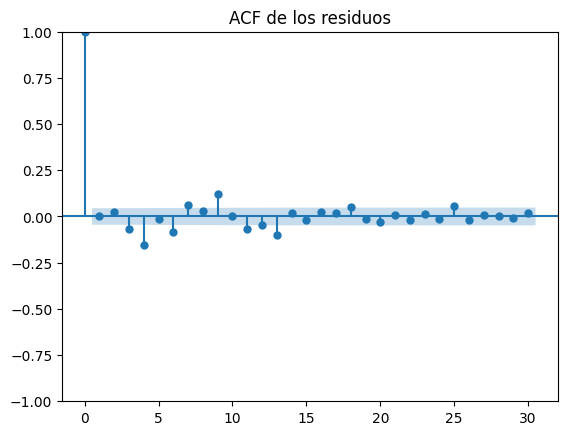

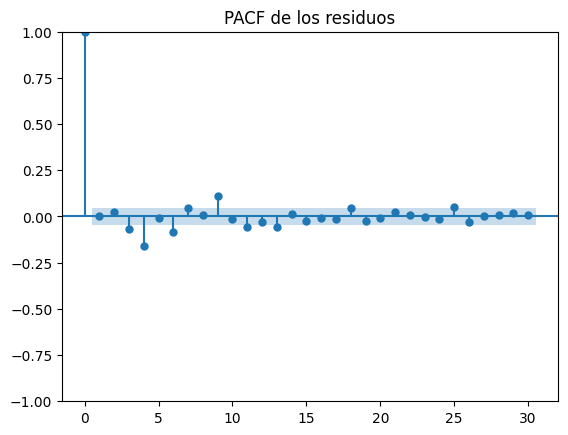

In [23]:
sm.graphics.tsa.plot_acf(residuals, lags=30)
plt.title("ACF de los residuos")
plt.show()

sm.graphics.tsa.plot_pacf(residuals, lags=30)
plt.title("PACF de los residuos")
plt.show()

_We observe in the correlagram the high and significant peaks through time on the model indicating autocorrelation. We can also see lags peaking at different periods (9/18/25) leaving the model with signs of seasonality._

In [24]:
def adf_test(series, name='Serie'):
    result = adfuller(series)
    print(f'ADF Test para {name}:')
    print(f'  Estadístico = {result[0]:.4f}')
    print(f'  p-valor = {result[1]:.4f}')
    print(f'  Lags usados = {result[2]}')
    print(f'  Observaciones usadas = {result[3]}')
    if result[1] <= 0.05:
        print("  → the series is stationary (reject H0)\n")
    else:
        print("  → the series is not stationary (fail to reject H0)\n")

In [25]:
adf_test(df['SP500R'], 'SP500R')
adf_test(df['GoldR'], 'GoldR')
adf_test(df['DXYR'], 'DXYR')

ADF Test para SP500R:
  Estadístico = -12.1094
  p-valor = 0.0000
  Lags usados = 12
  Observaciones usadas = 1902
  → the series is stationary (reject H0)

ADF Test para GoldR:
  Estadístico = -10.0687
  p-valor = 0.0000
  Lags usados = 21
  Observaciones usadas = 1893
  → the series is stationary (reject H0)

ADF Test para DXYR:
  Estadístico = -19.2965
  p-valor = 0.0000
  Lags usados = 5
  Observaciones usadas = 1909
  → the series is stationary (reject H0)



#### B) Ordinary Least Squares (OLS) with Seasonal Dummies


_**We try to eliminate the corresponding autocorrelation and seasonality problems with weekly dummies. However this method is not effective as we continue to suffer from these problems.**_

In [26]:
df['weekday'] = df.index.weekday
weekday_dummies = pd.get_dummies(df['weekday'], prefix='wd', drop_first=True)
df = pd.concat([df, weekday_dummies], axis=1)

In [27]:
df['month'] = df.index.month
month_dummies = pd.get_dummies(df['month'], prefix='m', drop_first=True)
df = pd.concat([df, month_dummies], axis=1)

In [28]:
X = df[['SP500R_lag1', 'SP500R_lag5', 'Yield10Y_change', 'DXYR', 
        'VIX_change', 'GoldR', 'RSI_SP500']]

In [29]:
X = pd.concat([X, weekday_dummies], axis=1)

In [30]:
X = sm.add_constant(X)

In [31]:
X = X.astype(float)

In [32]:
y = y.astype(float)

In [33]:
model = sm.OLS(df['SP500R'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 SP500R   R-squared:                       0.677
Model:                            OLS   Adj. R-squared:                  0.675
Method:                 Least Squares   F-statistic:                     362.4
Date:                Wed, 16 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:29:57   Log-Likelihood:                 6807.8
No. Observations:                1915   AIC:                        -1.359e+04
Df Residuals:                    1903   BIC:                        -1.352e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0090      0.001     

In [34]:
residuals = model.resid

In [35]:
result = adfuller(residuals)
print("ADF Test sobre los residuos del modelo:")
print(f"  Estadístico = {result[0]:.4f}")
print(f"  p-valor = {result[1]:.4f}")
print(f"  Lags usados = {result[2]}")
print(f"  Observaciones usadas = {result[3]}")

if result[1] <= 0.05:
    print("→ the series is stationary (reject H0)")
else:
    print("→ the series is not stationary (fail to reject H0)")

ADF Test sobre los residuos del modelo:
  Estadístico = -13.8727
  p-valor = 0.0000
  Lags usados = 12
  Observaciones usadas = 1902
→ the series is stationary (reject H0)


In [36]:
lb_test = acorr_ljungbox(residuals, lags=[5,10,15], return_df=True)
print("Test Ljung-Box de autocorrelación de residuos:")
print(lb_test)


Test Ljung-Box de autocorrelación de residuos:
       lb_stat     lb_pvalue
5    58.838870  2.111380e-11
10  114.233197  7.453407e-20
15  148.529550  4.724516e-24


_As the p-value is smaller than 0.05 we reject the HO and conclude there is autocorrelation in this model._

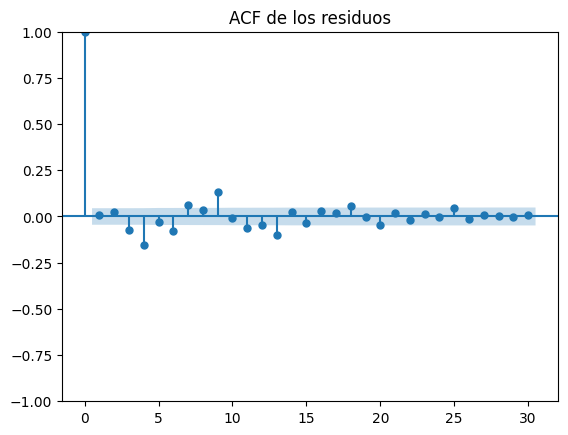

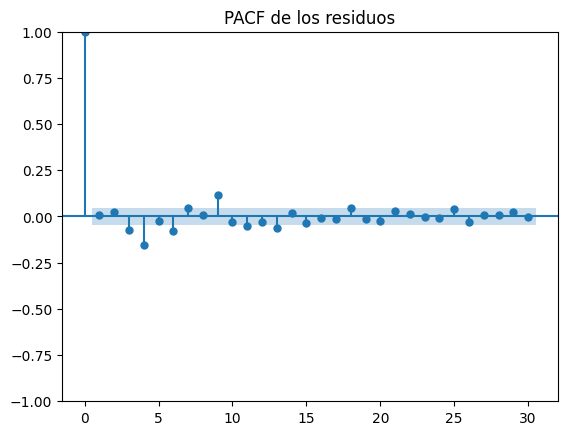

In [37]:
sm.graphics.tsa.plot_acf(residuals, lags=30)
plt.title("ACF de los residuos")
plt.show()

sm.graphics.tsa.plot_pacf(residuals, lags=30)
plt.title("PACF de los residuos")
plt.show()

_We observe in the correlagram the high and significant peaks through time on the model indicating autocorrelation. Same as the OLS without the Dummies. Thus, we fail to correct the autocorrelation problem of the Model._

# SARIMAX(4,0,4)

After different tests and models we decide the best way to eliminate model's autocorrelation is by creating a Sarimax model which solves Seasonality, and autocorrelation on the dependent and independent variables. 

### Model identification, Selection criteria & Overfitting prevention

To select (4,0,4) over lower-order specifications (e.g., ARMA(1,1), ARMA(2,2)), 
a grid search over orders p, q in [0, 5] was conducted (mainly in Grtl), targeting the 
Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC):

    AIC = 2k - 2*ln(L)
    BIC = k*ln(T) - 2*ln(L)

While dynamic asset prices often induce trade-offs where BIC favors parsimonious 
models, SARIMAX(4,0,4) minimized overall forecast variance and maximized the 
log-likelihood function (L) without introducing parameter redundancy.

Parameter dynamic test: High-order combinations can create cancellation roots 
in polynomial equations (1 - phi_1*B - ... - phi_p*B^p) = 0. Diagnostic checks 
confirmed that all roots of the characteristic polynomials for AR(4) and MA(4) 
lie strictly outside the unit circle, ensuring both causality (invertibility) 
and stationarity.

### Structural Autocorrelation & Long-Memory Behaviour: AR(4) & MA(4)

* Autoregressive (AR) Component p = 4:
  - The Partial Autocorrelation Function (PACF) displayed significant decay 
    and spikes up to lag 4, indicating that price discovery relies on a multi-day history
    (Investors' strategies induce short-term feedback loops persisting up to 4 trading sessions.)

* Moving Average (MA) Component q = 4:
  - The Autocorrelation Function (ACF) exhibited significant cuts off around lag 4.
  - Unanticipated macroeconomic shocks (e.g., unexpected Fed rate 
    guidance or earnings announcements) are not immediately absorbed in a single 
    period. The MA(4) filter captures the persistent propagation of these random 
    innovations (white noise errors epsilon_t) over a 4-day horizon as market 
    participants digest new information.

In [38]:
sns.set(style="whitegrid")

In [39]:
y = df['SP500R']
X = df[['DXYR', 'Yield10Y_change', 'VIX_change']]

In [40]:
model = SARIMAX(y, exog=X, order=(4,0,4), seasonal_order=(1,0,1,12))
fit = model.fit(disp=False)

In [41]:
print(fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                               SP500R   No. Observations:                 1915
Model:             SARIMAX(4, 0, 4)x(1, 0, [1], 12)   Log Likelihood                6745.711
Date:                              Wed, 16 Sep 2026   AIC                         -13463.422
Time:                                      11:30:04   BIC                         -13385.617
Sample:                                  02-04-2019   HQIC                        -13434.791
                                       - 06-05-2026                                         
Covariance Type:                                opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
DXYR               -0.4042      0.031    -13.094      0.000      -0.465      -0.344
Yiel

In [42]:
resid = fit.resid

In [43]:
adf_result = adfuller(y)
print("ADF Test")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

ADF Test
ADF Statistic: -12.1094
p-value: 0.0000


_The series is stationary (reject H0), we comply with the stationarity assumption_

In [44]:
lb_test = acorr_ljungbox(resid, lags=[1,5,10,12,24], return_df=True)
print(lb_test)


      lb_stat  lb_pvalue
1    0.010389   0.918816
5    0.959121   0.965795
10   6.785885   0.745492
12  10.689264   0.555720
24  28.351985   0.245474


_The series is not autocorrelated (fail to reject), we comply with the no autocorrelation assumption_

In [45]:
resid_std = resid / resid.std()

<Figure size 1200x400 with 0 Axes>

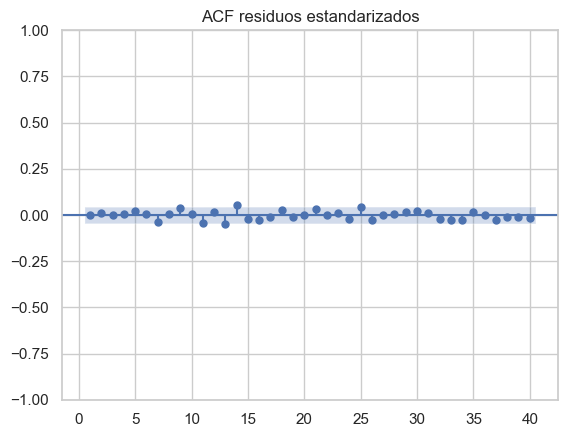

<Figure size 1200x400 with 0 Axes>

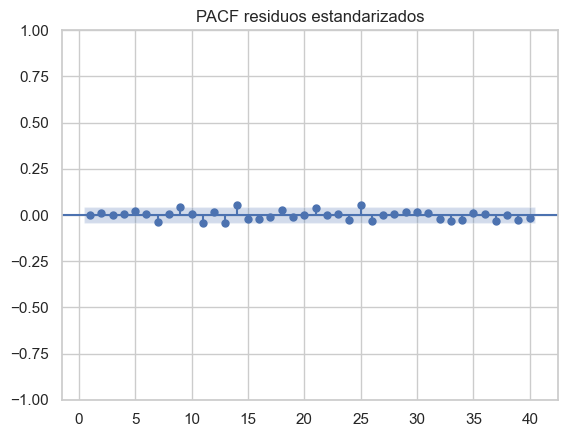

In [46]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,4))
plot_acf(resid_std, lags=40, alpha=0.05, zero=False)
plt.title('ACF residuos estandarizados')
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(resid_std, lags=40, alpha=0.05, zero=False)
plt.title('PACF residuos estandarizados')
plt.show()

_Lastly, we don't observe any strong indication of autocorrelation, heteroskedasticity nor seasonality on the correlogram. Hence, we can proceed to establish our model and continue with the forecasting proccess._

# Forecasting the SP500 

### SARIMAX forecast
After establishing our model we create a code which generates a 44-business-day (~2 month) price forecast for the S&P 500 by transforming log-return predictions back into price levels and plotting the results alongside confidence intervals.

1. Thereafter setting the horizon, we create exogenous future exogenous data (X_forecast) by repeating the last known values across a business-day index . It then calls _fit.get_forecast()_ to generate out-of-sample log-return predictions along with their lower and upper confidence bounds. To translate these predictions back into actual price levels, the code cumulatively sums the predicted log-returns and exponentiates them multiplied by the last known price, applying the exact same exponential transformation to convert the lower and upper confidence bounds into price levels.
  
2. Next, it builds a unified DataFrame (df_forecast) combining historical closing prices (SP500_Close) with the newly calculated forecast and confidence bounds, using NaN-padded series to align the future predictions neatly after the historical data.

3. Finally, the code uses Matplotlib to display the historical price series in blue and the SARIMAX forecast in red, shades the region between the upper and lower confidence intervals in pink.

4. Note that repeating the last known exogenous row assumes all feature values remain completely static over the 44-day forecast period, which may understate real-world market variance if those features are dynamic.

In [47]:
y = df['SP500R']
X = df[['DXYR', 'Yield10Y_change', 'VIX_change']]
last_price = df['SP500_Close'].iloc[-1]

In [48]:
model = SARIMAX(y, exog=X, order=(4,0,4), seasonal_order=(1,0,1,12))
fit = model.fit(disp=False)
print(fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                               SP500R   No. Observations:                 1915
Model:             SARIMAX(4, 0, 4)x(1, 0, [1], 12)   Log Likelihood                6745.711
Date:                              Wed, 16 Sep 2026   AIC                         -13463.422
Time:                                      11:30:11   BIC                         -13385.617
Sample:                                  02-04-2019   HQIC                        -13434.791
                                       - 06-05-2026                                         
Covariance Type:                                opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
DXYR               -0.4042      0.031    -13.094      0.000      -0.465      -0.344
Yiel

In [49]:
h_forecast = 44
X_forecast = pd.DataFrame([X.iloc[-1]]*h_forecast, 
                          columns=X.columns, 
                          index=pd.bdate_range(start=y.index[-1]+pd.Timedelta(days=1), periods=h_forecast))

forecast_res = fit.get_forecast(steps=h_forecast, exog=X_forecast)
yhat = forecast_res.predicted_mean
conf_int = forecast_res.conf_int()

In [50]:
cum_returns = yhat.cumsum()
forecast_price = last_price * np.exp(cum_returns)

cum_lower = conf_int.iloc[:,0].cumsum()
cum_upper = conf_int.iloc[:,1].cumsum()
conf_lower = last_price * np.exp(cum_lower)
conf_upper = last_price * np.exp(cum_upper)

In [51]:
df_forecast = pd.DataFrame({
    'SP500_Close': pd.concat([df['SP500_Close'], forecast_price]),
    'Forecast': pd.concat([pd.Series([np.nan]*len(df), index=df.index), forecast_price]),
    'Lower_CI': pd.concat([pd.Series([np.nan]*len(df), index=df.index), conf_lower]),
    'Upper_CI': pd.concat([pd.Series([np.nan]*len(df), index=df.index), conf_upper])
})

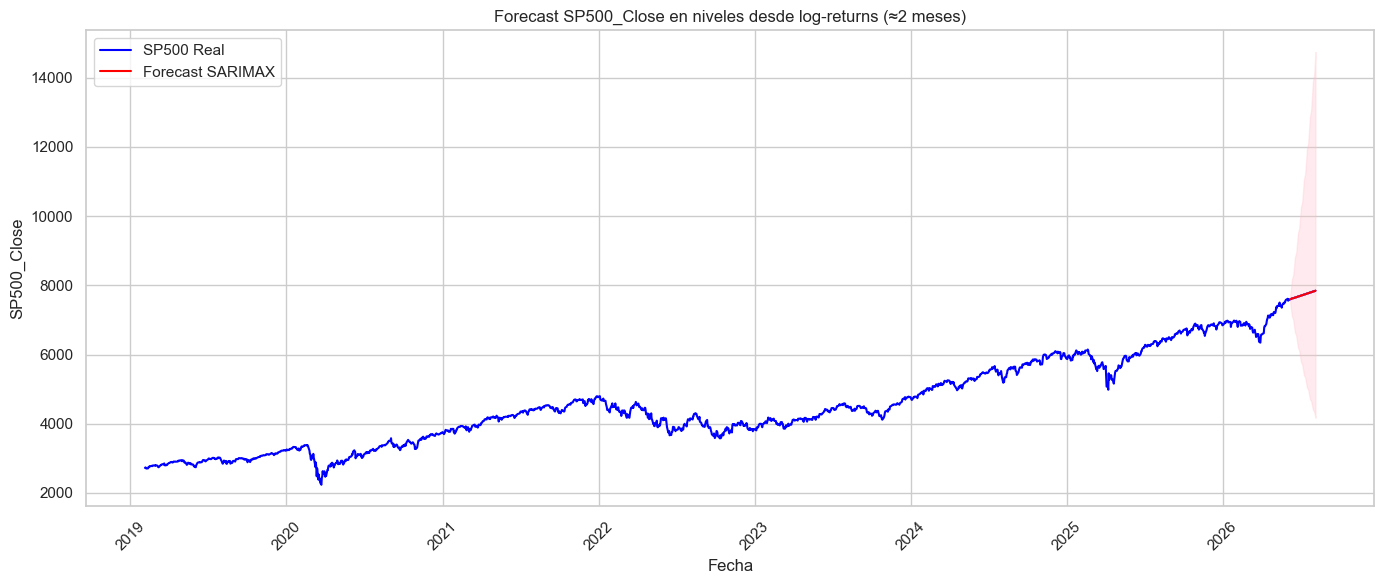

In [52]:
plt.figure(figsize=(14,6))
plt.plot(df_forecast.index, df_forecast['SP500_Close'], label='SP500 Real', color='blue')
plt.plot(df_forecast.index, df_forecast['Forecast'], label='Forecast SARIMAX', color='red')
plt.fill_between(df_forecast.index, df_forecast['Lower_CI'], df_forecast['Upper_CI'], color='pink', alpha=0.3)
plt.title(f'Forecast SP500_Close en niveles desde log-returns (≈2 meses)')
plt.xlabel('Fecha')
plt.ylabel('SP500_Close')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

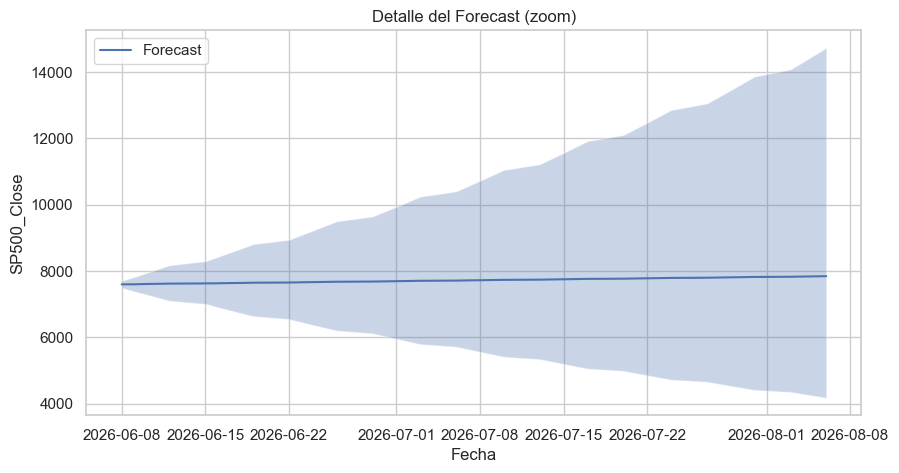

In [53]:
plt.figure(figsize=(10,5))
plt.plot(forecast_price.index, forecast_price, label='Forecast')
plt.fill_between(forecast_price.index, conf_lower, conf_upper, alpha=0.3)
plt.title('Detalle del Forecast (zoom)')
plt.xlabel('Fecha')
plt.ylabel('SP500_Close')
plt.grid(True)
plt.legend()
plt.show()

### MONTECARLO simulations
*Unlike standard point forecasts that output a single expected value, the Montecarlo simulations generates full path realizations, creating a visual fan chart that illustrates how potential future trajectories can disperse over time and allowing you to evaluate path-dependent risks like maximum drawdown over the 44-period window.*

1. To create the simulations the Montecarlo code draws 100 independent random samples (repetitions) of 44 sequential steps forward from your fitted time-series model (e.g., SARIMAX). Each path represents a plausible future sequence of daily log-returns based on the estimated model parameters and random error shocks.

2. Then the code loops through the first 20 simulated price paths out of the 100 generated, plotting them in semi-transparent overlay. This visualizes the dispersion and potential range of future market movements.

3. Next, We extracted various indicators from the simulations such as: probability of rise or fall, probability of rebound, confidence interval or pessimistic and optimistic scenarios.

4. Finally, we plot a Gaussian bell curve with the 2 month simulated distribution of the sp500 prices. And a Chart with the continuous relationship between initial drop and probability of rebound.

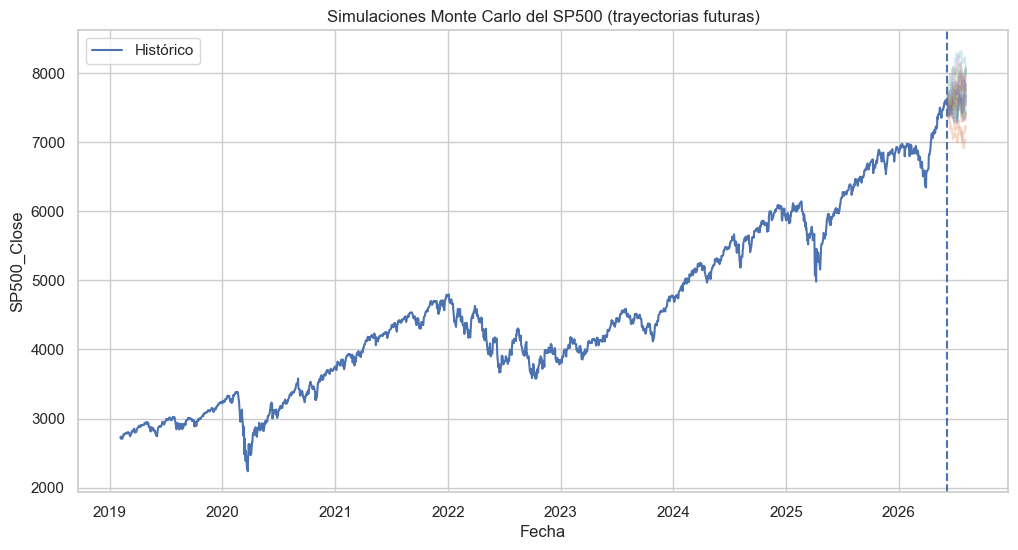

In [54]:
sim = fit.simulate(nsimulations=44, repetitions=100)

sim_prices = last_price * np.exp(sim.cumsum())

plt.figure(figsize=(12,6))
plt.plot(df['SP500_Close'], label='Histórico')

for i in range(20):
    plt.plot(forecast_price.index, sim_prices.iloc[:, i], alpha=0.3)

plt.axvline(df.index[-1], linestyle='--')
plt.title('Simulaciones Monte Carlo del SP500 (trayectorias futuras)')
plt.xlabel('Fecha')
plt.ylabel('SP500_Close')
plt.legend()
plt.grid(True)
plt.show()

In [55]:
h = 44
n_sim = 2000  
sim = fit.simulate(nsimulations=h, repetitions=n_sim)
sim_prices = last_price * np.exp(sim.cumsum())
final_prices = sim_prices.iloc[-1]


In [56]:
print("KPIs of the Montecarlo Simulation:")
print()
prob_up = (final_prices > last_price).mean()
prob_down = (final_prices < last_price).mean()

print("Probabilidad de subida:", round(prob_up*100,2), "%")
print("Probabilidad de bajada:", round(prob_down*100,2), "%")
prob_drop_5 = (final_prices < last_price*0.95).mean()
prob_drop_10 = (final_prices < last_price*0.90).mean()
print()
print("Prob caída >5%:", round(prob_drop_5*100,2), "%")
print("Prob caída >10%:", round(prob_drop_10*100,2), "%")
VaR_95 = np.percentile(final_prices, 5)
VaR_99 = np.percentile(final_prices, 1)
print()
print("VaR 95%:", round(VaR_95,2))
print("VaR 99%:", round(VaR_99,2))

print("Pérdida VaR 95%:", round((VaR_95/last_price-1)*100,2), "%")
p5  = np.percentile(final_prices, 5)
p50 = np.percentile(final_prices, 50)
p95 = np.percentile(final_prices, 95)
print()
print("Escenario pesimista (5%):", round(p5,2))
print("Mediana:", round(p50,2))
print("Escenario optimista (95%):", round(p95,2))


KPIs of the Montecarlo Simulation:

Probabilidad de subida: 50.15 %
Probabilidad de bajada: 49.85 %

Prob caída >5%: 10.15 %
Prob caída >10%: 0.6 %

VaR 95%: 7091.35
VaR 99%: 6880.26
Pérdida VaR 95%: -6.5 %

Escenario pesimista (5%): 7091.35
Mediana: 7587.23
Escenario optimista (95%): 8117.15


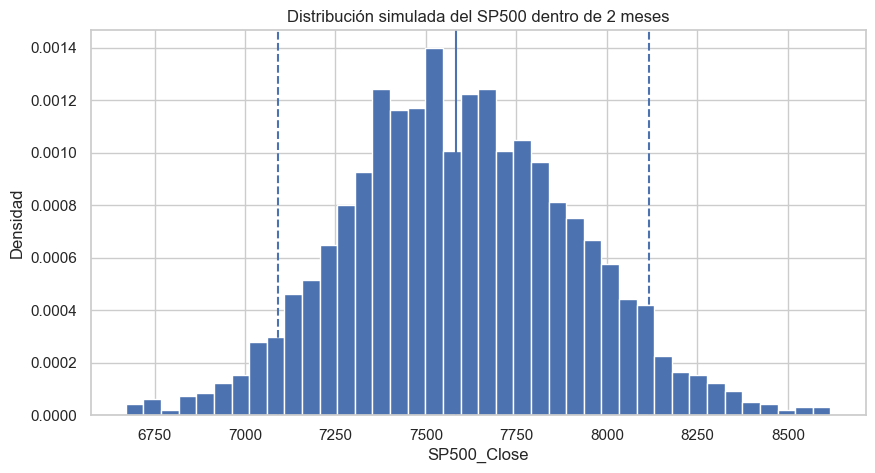

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(final_prices, bins=40, density=True)
plt.axvline(last_price)
plt.axvline(p5, linestyle='--')
plt.axvline(p95, linestyle='--')

plt.title("Distribución simulada del SP500 dentro de 2 meses")
plt.xlabel("SP500_Close")
plt.ylabel("Densidad")
plt.show()

In [58]:
X = 0.02    # caída del 2%
Y = 0.015   # rebote del 1.5%
Z = 5       # ventana de 5 días

In [59]:
def rebound_probability_simulated(sim_prices, X, Y, Z):
    total_events = 0
    rebound_events = 0

    for col in sim_prices.columns:
        prices = sim_prices[col].values

        for t in range(1, len(prices) - Z):
            drop = prices[t] / prices[t-1] - 1

            if drop <= -X:
                total_events += 1
                future_max = prices[t+1:t+Z+1].max()
                rebound = future_max / prices[t] - 1

                if rebound >= Y:
                    rebound_events += 1

    if total_events == 0:
        return np.nan

    return rebound_events / total_events


In [60]:
prob_rebound = rebound_probability_simulated(
    sim_prices,
    X=X,
    Y=Y,
    Z=Z
)

print(f"Probabilidad simulada de rebote: {prob_rebound:.2%}")


Probabilidad simulada de rebote: 47.29%


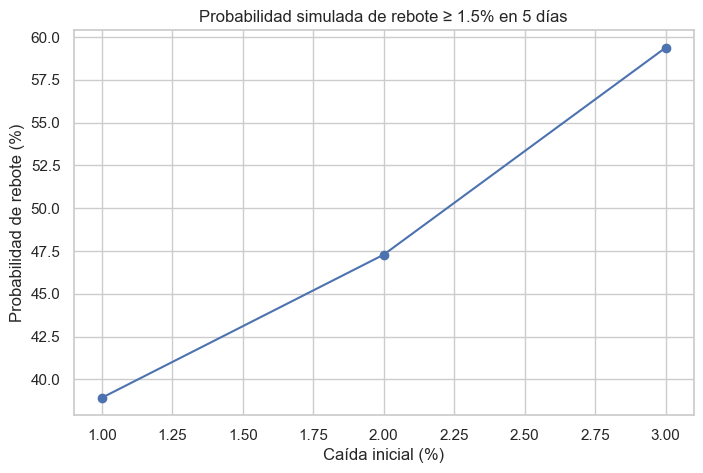

In [61]:
Xs = np.arange(0.01, 0.06, 0.01)
probs = []

for x in Xs:
    p = rebound_probability_simulated(sim_prices, X=x, Y=Y, Z=Z)
    probs.append(p)

plt.figure(figsize=(8,5))
plt.plot(Xs*100, np.array(probs)*100, marker='o')
plt.xlabel("Caída inicial (%)")
plt.ylabel("Probabilidad de rebote (%)")
plt.title(f"Probabilidad simulada de rebote ≥ {Y*100:.1f}% en {Z} días")
plt.grid(True)
plt.show()


# GARCH MODEL 

Given that our SARIMA(4,0,4) model is based on criteria that lead to overfitting and assumes homoscedastic variance (constant over time), it will be necessary to modify it to incorporate conditional heteroscedasticity—a characteristic most common in the financial sector (periods of high volatility).

### Combining GARCH in SARIMA

Combining SARIMA with GARCH ddresses both the expected path of the series and the time-varying risk surrounding it.

- SARIMA Models the Mean. It captures linear trends, seasonality, and serial correlation to predict the expected future values of the series. However, SARIMA assumes standard constant error variance (homoskedasticity).
  
- GARCH Models the Volatility.  Financial asset returns exhibit volatility clustering—periods of high turbulence follow high turbulence, and calm periods follow calm periods. GARCH fits the residuals ($\epsilon_t$) extracted from SARIMA to capture this dynamic risk.

- In the combination SARIMA handles the point forecast (where the index is heading), while GARCH provides accurate, time-varying risk bounds (how much it is likely to fluctuate).

### Steps of the combination

 1. First, we fit a SARIMAX(4,0,4)x(1,0,1,5) model on the S&P 500 close price to capture non-seasonal autorregressive/moving average dynamics along with a weekly (5-day) seasonal component.
 2. Then, we extract the residuals from the SARIMA model and fit a standard GARCH(1,1) model using the arch library to estimate conditional variance over time. We make the model's variance depend on past variances and past errors (1,1). $$\begin{cases}  Y_t = \beta_0(1-\rho) + \rho Y_{t-1} + \beta_1 X_t - \beta_1 \rho X_{t-1} + \varepsilon_t \\ \sigma_t^2 = \omega + \alpha_1 \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2  \end{cases}$$
 3. Next, we Forecast the sarima to project the 5-day expected mean price predictions and its standard analytical confidence bounds. And we forecast the GARCH to project the conditional variance 5 steps ahead and calculate the standard deviation by taking the square root (np.sqrt) of the forecasted variances.
 4. Finally, we construct the forecast_df indexed across the next 5 business days, storing the SARIMA point predictions, lower/upper bounds, and the GARCH volatility estimates side by side. And plot the last 50 historical closing prices alongside the 5-day SARIMA point forecast.

In [62]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model
import warnings
warnings.filterwarnings("ignore")

In [63]:
returns = df['SP500_Close'].pct_change().dropna()

In [64]:
sarima_model = SARIMAX(df['SP500_Close'], order=(4,0,4), seasonal_order=(1,0,1,5), enforce_stationarity=False, enforce_invertibility=False)
sarima_res = sarima_model.fit(disp=False)

In [65]:
residuals = sarima_res.resid
garch_model = arch_model(residuals, vol='Garch', p=1, q=1)
garch_res = garch_model.fit(disp='off')

In [66]:
sarima_forecast = sarima_res.get_forecast(steps=5)
sarima_pred = sarima_forecast.predicted_mean
sarima_ci = sarima_forecast.conf_int()

In [67]:
garch_forecast = garch_res.forecast(horizon=5)
garch_vol = np.sqrt(garch_forecast.variance.values[-1,:])

In [68]:
forecast_df = pd.DataFrame({
'SARIMA_Forecast': sarima_pred.values,
'Lower_CI': sarima_ci.iloc[:,0].values,
'Upper_CI': sarima_ci.iloc[:,1].values,
'GARCH_Volatility': garch_vol
}, index=pd.date_range(start=df['SP500_Close'].index[-1] + pd.Timedelta(days=1), periods=5))

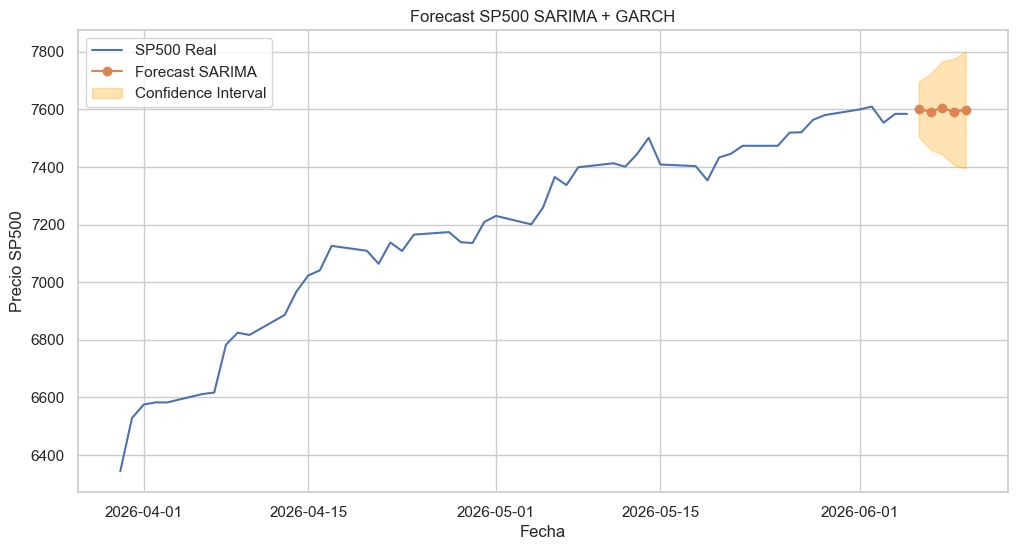

In [69]:
plt.figure(figsize=(12,6))
plt.plot(df['SP500_Close'][-50:], label='SP500 Real')
plt.plot(forecast_df['SARIMA_Forecast'], label='Forecast SARIMA', marker='o')
plt.fill_between(forecast_df.index, forecast_df['Lower_CI'], forecast_df['Upper_CI'], color='orange', alpha=0.3, label='Confidence Interval')
plt.title('Forecast SP500 SARIMA + GARCH')
plt.xlabel('Fecha')
plt.ylabel('Precio SP500')
plt.legend()
plt.show()

In [70]:
n_simulations = 1000
horizon = len(forecast_df)

In [71]:
mc_forecasts = np.zeros((n_simulations, horizon))

for i in range(n_simulations):
    shocks = np.random.normal(0, garch_vol) 
    mc_forecasts[i,:] = sarima_pred.values + shocks

In [72]:
mc_summary = pd.DataFrame({
    'MC_Mean': mc_forecasts.mean(axis=0),
    'MC_5th_Percentile': np.percentile(mc_forecasts, 5, axis=0),
    'MC_95th_Percentile': np.percentile(mc_forecasts, 95, axis=0)
}, index=forecast_df.index)

In [73]:
last_close = df['SP500_Close'].iloc[-1]
prob_up = (mc_forecasts > last_close).mean(axis=0)
prob_down = 1 - prob_up
prob_df = pd.DataFrame({'Prob_Up': prob_up, 'Prob_Down': prob_down}, index=forecast_df.index)

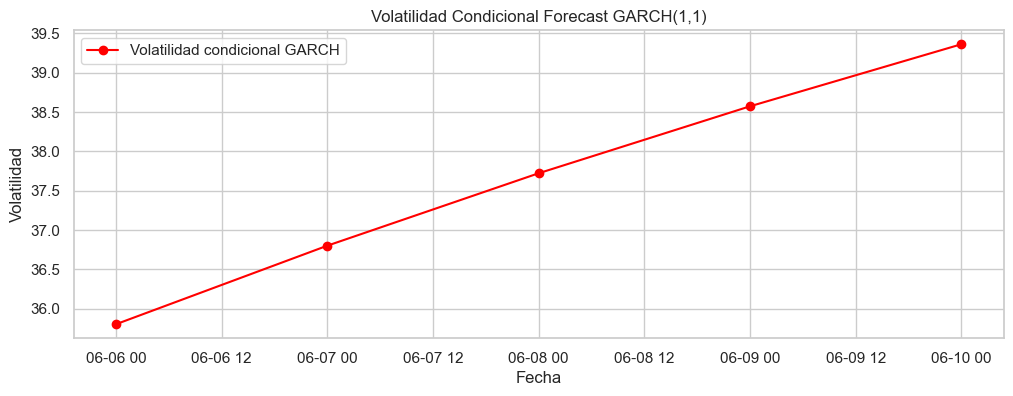

(            SARIMA_Forecast     Lower_CI     Upper_CI  GARCH_Volatility
 2026-06-06      7600.354058  7503.740298  7696.967819         35.800033
 2026-06-07      7592.077282  7460.699143  7723.455422         36.799372
 2026-06-08      7605.043311  7443.842334  7766.244288         37.720897
 2026-06-09      7591.353774  7406.816486  7775.891061         38.572874
 2026-06-10      7598.274638  7394.863033  7801.686243         39.362314,
                 MC_Mean  MC_5th_Percentile  MC_95th_Percentile
 2026-06-06  7601.597351        7542.257849         7662.410782
 2026-06-07  7590.806170        7529.842648         7650.204692
 2026-06-08  7606.304334        7545.811730         7665.413135
 2026-06-09  7588.710195        7528.346487         7650.555206
 2026-06-10  7598.167230        7534.022751         7663.211882,
             Prob_Up  Prob_Down
 2026-06-06    0.693      0.307
 2026-06-07    0.564      0.436
 2026-06-08    0.709      0.291
 2026-06-09    0.547      0.453
 2026-06-10    0

In [74]:
plt.figure(figsize=(12,4))
plt.plot(forecast_df['GARCH_Volatility'], color='red', marker='o', label='Volatilidad condicional GARCH')
plt.title('Volatilidad Condicional Forecast GARCH(1,1)')
plt.xlabel('Fecha')
plt.ylabel('Volatilidad')
plt.legend()
plt.show()


forecast_df, mc_summary, prob_df

_This plot displays the 5-day forecasted conditional volatility ($\sigma_t$) generated by the GARCH(1,1), the sarima forecast with it's respective confidence intervals as well as the Montecarlo Simulation's Mean, 5th and 95th percentiles._

# Final Model

### (SARIMAX-GARCH) combined with Monte Carlo simulation

* SARIMAX(4,0,4) with Exogenous Features: Captures the conditional mean ($\mu_t$) of log-returns using past return dependencies, a constant drift term, and macroeconomic signals (Yield10Y_change, DXYR, VIX_change).
* GARCH(1,1) with Student's $t$-Distribution: Fits the scaled residual errors from the SARIMAX model to capture conditional heteroskedasticity (volatility clustering) and fat-tailed tail risk ($\nu$ degrees of freedom).
* Monte Carlo Simulation: Generates 5,000 empirical price trajectories by compounding predicted returns combined with dynamic, GARCH-scaled random shocks drawn from a Student's $t$-distribution.

### Problems with the (4,0,4)

 *Before continuing with our project we decide to change our (p,q) in the SARIMA, why?*
 
* A SARIMA(4,0,4) model causes severe overfitting on S&P 500 return series because financial log-returns exhibit an extremely low signal-to-noise ratio and weak serial autocorrelation. By estimating eight separate autoregressive ($\phi_1, \dots, \phi_4$) and moving-average ($\theta_1, \dots, \theta_4$) parameters alongside exogenous variables, the model stops learning genuine market structure and instead memorizes random historical noise. This over-parameterization inflates the model's in-sample fit while severely degrading out-of-sample forecasting power, introducing artificial oscillations into the predicted mean path ($\mu_t$). Furthermore, because the GARCH(1,1) model fits directly onto the SARIMA residuals ($\epsilon_t = y_t - \hat{\mu}_t$), an overfitted mean equation leaves behind artificially clean residuals inside the training set, distorting the GARCH parameter estimates ($\alpha$ and $\beta$) and compromising the dynamic conditional volatility forecast ($\sigma_t^2$)

### THE SARIMA(1,0,1) GARCH(1,1)

Due to issues with the (4,0,4) configuration, we decided to modify the model again by reducing the SARIMA (p,q) parameters—we had already analyzed these parameters previously, but the inclusion of GARCH in the model changes everything. A SARIMA(1,0,1)-GARCH(1,1) framework adheres to the econometric principle of parsimony. It uses a single AR(1) and MA(1) term to capture the slight first-order dependency present in daily financial returns without fitting white noise. While the SARIMA(4,0,4) model suffers from high complexity, inflated Bayesian Information Criterion (BIC) penalties, and poor generalization on unseen data, the SARIMA(1,0,1) specification minimizes BIC, isolates the mean equation cleanly, and leaves true, unmanipulated residual variance for the GARCH(1,1) component. This allows the GARCH model to execute its primary function—capturing volatility clustering and heavy-tailed risk—yielding far more robust, realistic out-of-sample price projections and confidence bounds.

### Execution Process

  1. **Data Cleaning**: First, we filter missing values across closing prices, return series, and exogenous indicators to maintain continuous time-series integrity.
  2. **SARIMAX Fitting & Exogenous Projection**: Then, we fit the $(1,0,1)$ return specification. For future inputs over the 30-day window, we forward-fill the mean of the last 20 observations across exogenous variables to anchor the expected return mean ($\mu_f$).
  3. **GARCH Estimation & Volatility Projection**: Next,  We multiply SARIMAX residuals by 100 for numerical stability, fit a GARCH(1,1) specification under $t$-distributed errors, and forecast the out-of-sample conditional volatility ($\sigma_f$), re-scaling back to return units.
  4. **Monte Carlo Path Generation**: Finally, For each of the 5,000 paths over 30 days, random shocks ($z_t \sim t_{\nu}$) are drawn and scaled by GARCH volatility.

### Model Analytics

The analysis calculates the percentage of simulated paths where future price exceeds current price ($P_t > P_0$) at 1-day, 5-day, and 22-day horizons, categorizing market bias into Bullish ($\ge 60\%$), Bearish ($\le 40\%$), or Neutral.
It also sets critical support at the 10th percentile and resistance at the 90th percentile of final 30-day simulated prices.
We also create a dashboard visualization that plots 60 days of historical prices alongside the expected mean trajectory, 50% interquartile range, 90% confidence bounds, and key horizontal support/resistance levels to help us with the visualization and analysis.


   TEST DE LJUNG-BOX: RESIDUOS ESTANDARIZADOS (MEDIA)
    Estadístico Q   p-valor
5       22.135933  0.000493
10      26.562055  0.003053
15      33.074784  0.004583
20      37.595073  0.009920

   TEST DE LJUNG-BOX: RESIDUOS CUADRADOS (VOLATILIDAD / ARCH)
    Estadístico Q   p-valor
5        4.035343  0.544339
10       5.606958  0.847134
15       8.048311  0.921831
20       9.699912  0.973293


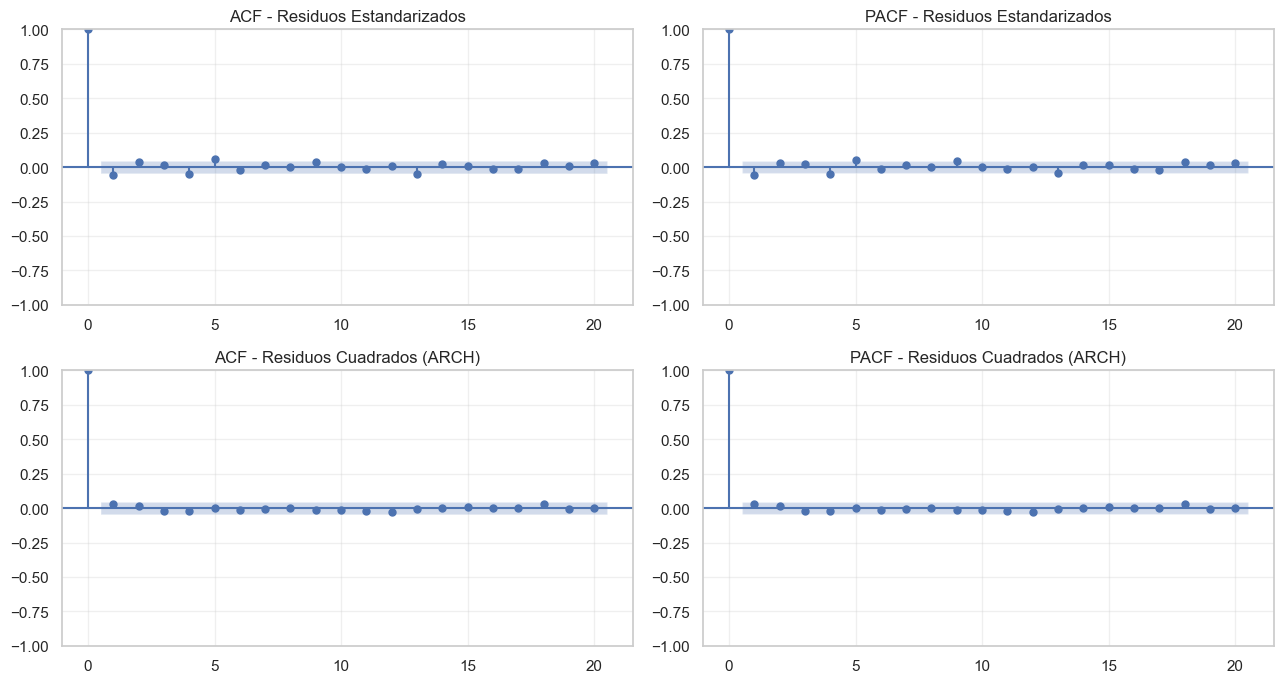

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Preparación de datos
exog_vars = ['Yield10Y_change', 'DXYR', 'VIX_change']
df_c = df.dropna(subset=['SP500_Close', 'SP500R'] + exog_vars).copy()

# 2. Ajuste del modelo SARIMAX(1,0,1) y GARCH(1,1)
mod_sarima = SARIMAX(df_c['SP500R'], exog=df_c[exog_vars], order=(1,0,1), trend='c').fit(disp=False)
mod_garch = arch_model(mod_sarima.resid * 100, vol='Garch', p=1, q=1, dist='t').fit(disp=False)

# 3. Obtención de residuos estandarizados
# std_resid representa: \tilde{\varepsilon}_t = e_t / \hat{\sigma}_t
std_resid = mod_garch.std_resid.dropna()

# 4. Test de Ljung-Box en residuos estandarizados y al cuadrado
lags_to_test = [5, 10, 15, 20]
lb_mean = acorr_ljungbox(std_resid, lags=lags_to_test, return_df=True)
lb_vol = acorr_ljungbox(std_resid**2, lags=lags_to_test, return_df=True)

# 5. Reporte numérico en consola
print("=" * 65)
print("   TEST DE LJUNG-BOX: RESIDUOS ESTANDARIZADOS (MEDIA)")
print("=" * 65)
print(lb_mean.rename(columns={'lb_stat': 'Estadístico Q', 'lb_pvalue': 'p-valor'}))

print("\n" + "=" * 65)
print("   TEST DE LJUNG-BOX: RESIDUOS CUADRADOS (VOLATILIDAD / ARCH)")
print("=" * 65)
print(lb_vol.rename(columns={'lb_stat': 'Estadístico Q', 'lb_pvalue': 'p-valor'}))

# 6. Diagnóstico gráfico (Correlogramas ACF y PACF)
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# Fila 1: Estructura de la Media (Residuos estandarizados)
plot_acf(std_resid, ax=axes[0, 0], lags=20, title='ACF - Residuos Estandarizados')
plot_pacf(std_resid, ax=axes[0, 1], lags=20, title='PACF - Residuos Estandarizados')

# Fila 2: Estructura de la Volatilidad (Residuos estandarizados al cuadrado)
plot_acf(std_resid**2, ax=axes[1, 0], lags=20, title='ACF - Residuos Cuadrados (ARCH)')
plot_pacf(std_resid**2, ax=axes[1, 1], lags=20, title='PACF - Residuos Cuadrados (ARCH)')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

_As can be seen from the comparison between the two models (SARIMA with and without GARCH), the GARCH model corrects all variance-related issues and resolves the autocorrelation problem, as confirmed by the Ljung-Box test and the correlogram._

     INFORME DE SENTIMIENTO Y NIVELES (S&P 500)
Precio de Cierre Actual: 7584.31
-------------------------------------------------------
HORIZONTE    | PROBABILIDAD ALCISTA | SENTIMIENTO
-------------------------------------------------------
Diario (24h) |             54.50% | NEUTRAL 🟡
Semanal (5d) |             55.72% | NEUTRAL 🟡
Mensual (22d)|             58.15% | NEUTRAL 🟡
-------------------------------------------------------
NIVELES CRÍTICOS PRÓXIMOS 30 DÍAS:
🚀 Resistencia (Vender/Take Profit): 8261.17
🛡️ Soporte (Comprar/Stop Loss):      7134.30

      MÉTRICAS DE RIESGO DE MERCADO (MONTE CARLO 30D)
VaR  95% :  8.06%  | Pérdida Máx Esperada: $611.50
CVaR 95% : 10.30%  | Pérdida Prom en Cola: $781.02
-------------------------------------------------------
VaR  99% : 11.59%  | Pérdida Máx Esperada: $878.97
CVaR 99% : 13.35%  | Pérdida Prom en Cola: $1,012.85

      VALORES PRONOSTICADOS (USD) - 5 DÍAS
     Fecha Precio Esperado Límite Inf (95%) Límite Sup (95%)
2026-06-08       

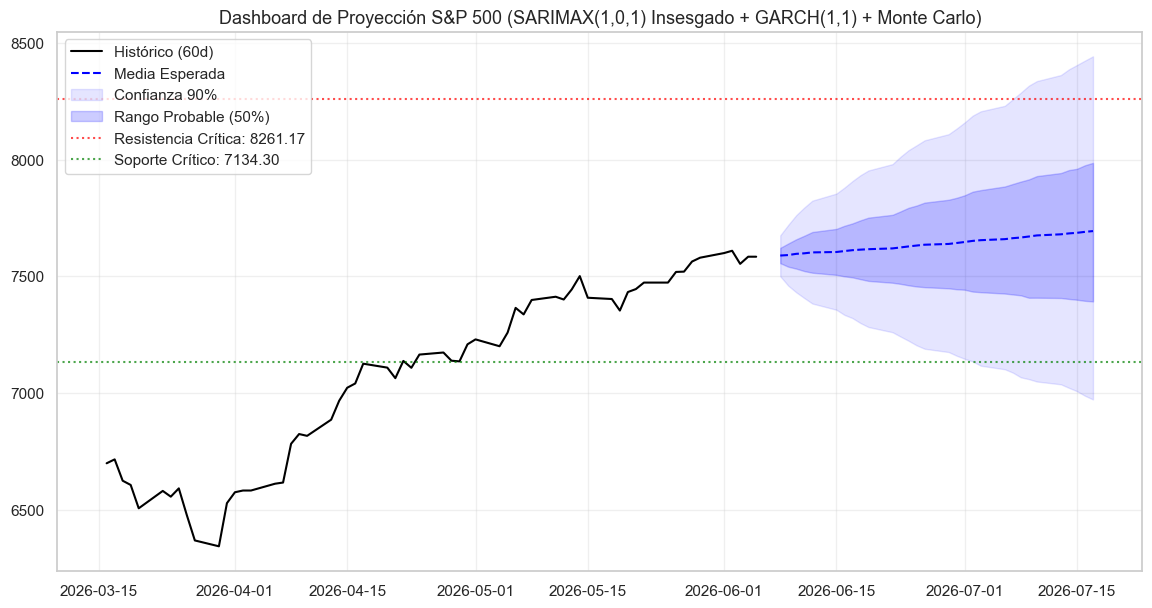

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model

# 1. Limpieza y generación de exógenas retardadas (Lag 1 insesgado)
exog_vars = ['Yield10Y_change', 'DXYR', 'VIX_change']
exog_lags = [f"{var}_lag" for var in exog_vars]

# Forzamos el retardo t-1 para evitar Data Leakage
for var, lag_var in zip(exog_vars, exog_lags):
    if df[var].dtype == 'object':
        df[var] = df[var].astype(str).str.replace(',', '')
    df[lag_var] = pd.to_numeric(df[var], errors='coerce').shift(1)

cols_to_fix = ['SP500_Close', 'SP500R'] + exog_lags
df_c = df.dropna(subset=cols_to_fix).copy()

# 2. Ajuste optimizado insesgado: SARIMAX(1,0,1) con exog(t-1) + GARCH(1,1)
mod_sarima = SARIMAX(df_c['SP500R'], exog=df_c[exog_lags], order=(1, 0, 1), trend='c').fit(disp=False)
mod_garch = arch_model(mod_sarima.resid * 100, vol='Garch', p=1, q=1, dist='t').fit(disp=False)

# 3. Monte Carlo Vectorizado (10,000 trayectorias a 30 días)
np.random.seed(42)
n_days, n_sims = 30, 10000
last_p, last_date = df_c['SP500_Close'].iloc[-1], df_c.index[-1]

# Proyección de exógenas basadas en el comportamiento reciente de los lags
f_exog = pd.concat([pd.DataFrame(df_c[exog_lags].tail(5).mean()).T] * n_days, ignore_index=True)

# Forecast de media y volatilidad condicional
mu_f = mod_sarima.forecast(steps=n_days, exog=f_exog)
vol_f = np.sqrt(mod_garch.forecast(horizon=n_days).variance.values[-1]) / 100

# Simulación matricial
dof = mod_garch.params.get('nu', 10)
shocks = np.random.standard_t(df=dof, size=(n_sims, n_days))
sim_future = last_p * np.exp(np.cumsum(mu_f.values + vol_f * shocks, axis=1))

# 4. Cálculo de Probabilidades y Niveles Críticos
prob = lambda d: (sim_future[:, d - 1] > last_p).mean()
get_sentiment = lambda p: "BULLISH 🟢" if p >= 0.60 else ("BEARISH 🔴" if p <= 0.40 else "NEUTRAL 🟡")

prob_d, prob_w, prob_m = prob(1), prob(5), prob(22)
resistencia_30d, soporte_30d = np.percentile(sim_future[:, -1], [90, 10])

# 5. Métricas de Riesgo de Mercado (VaR y CVaR a 30 días)
retornos_sim_30d = (sim_future[:, -1] - last_p) / last_p
var_95_pct = -np.percentile(retornos_sim_30d, 5)
var_99_pct = -np.percentile(retornos_sim_30d, 1)

cvar_95_pct = -retornos_sim_30d[retornos_sim_30d <= -var_95_pct].mean()
cvar_99_pct = -retornos_sim_30d[retornos_sim_30d <= -var_99_pct].mean()

# --- INFORME DE SENTIMIENTO ---
print("=" * 55)
print("     INFORME DE SENTIMIENTO Y NIVELES (S&P 500)")
print("=" * 55)
print(f"Precio de Cierre Actual: {last_p:.2f}")
print("-" * 55)
print(f"HORIZONTE    | PROBABILIDAD ALCISTA | SENTIMIENTO")
print("-" * 55)
print(f"Diario (24h) | {prob_d:18.2%} | {get_sentiment(prob_d)}")
print(f"Semanal (5d) | {prob_w:18.2%} | {get_sentiment(prob_w)}")
print(f"Mensual (22d)| {prob_m:18.2%} | {get_sentiment(prob_m)}")
print("-" * 55)
print(f"NIVELES CRÍTICOS PRÓXIMOS 30 DÍAS:")
print(f"🚀 Resistencia (Vender/Take Profit): {resistencia_30d:.2f}")
print(f"🛡️ Soporte (Comprar/Stop Loss):      {soporte_30d:.2f}")
print("=" * 55 + "\n")

# --- MÉTRICAS DE RIESGO DE MERCADO (VaR y CVaR) ---
print("=" * 55)
print("      MÉTRICAS DE RIESGO DE MERCADO (MONTE CARLO 30D)")
print("=" * 55)
print(f"VaR  95% : {var_95_pct:6.2%}  | Pérdida Máx Esperada: ${last_p * var_95_pct:,.2f}")
print(f"CVaR 95% : {cvar_95_pct:6.2%}  | Pérdida Prom en Cola: ${last_p * cvar_95_pct:,.2f}")
print("-" * 55)
print(f"VaR  99% : {var_99_pct:6.2%}  | Pérdida Máx Esperada: ${last_p * var_99_pct:,.2f}")
print(f"CVaR 99% : {cvar_99_pct:6.2%}  | Pérdida Prom en Cola: ${last_p * cvar_99_pct:,.2f}")
print("=" * 55 + "\n")

# --- VALORES PRONOSTICADOS (PRIMEROS 5 DÍAS) ---
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=n_days, freq='B')
df_resumen = pd.DataFrame({
    'Fecha': future_dates[:5],
    'Precio Esperado': np.mean(sim_future[:, :5], axis=0),
    'Límite Inf (95%)': np.percentile(sim_future[:, :5], 5, axis=0),
    'Límite Sup (95%)': np.percentile(sim_future[:, :5], 95, axis=0)
})

print("=" * 55)
print("      VALORES PRONOSTICADOS (USD) - 5 DÍAS")
print("=" * 55)
print(df_resumen.to_string(index=False, formatters={
    'Fecha': lambda x: x.strftime('%Y-%m-%d'),
    'Precio Esperado': '{:,.2f}'.format,
    'Límite Inf (95%)': '{:,.2f}'.format,
    'Límite Sup (95%)': '{:,.2f}'.format
}))
print("=" * 55 + "\n")

# --- DASHBOARD GRÁFICO INTEGRADO ---
plt.figure(figsize=(14, 7))
plt.plot(df_c['SP500_Close'].tail(60), color='black', lw=1.5, label='Histórico (60d)')
plt.plot(future_dates, np.mean(sim_future, axis=0), color='blue', ls='--', label='Media Esperada')

plt.fill_between(future_dates, np.percentile(sim_future, 5, axis=0), 
                 np.percentile(sim_future, 95, axis=0), color='blue', alpha=0.1, label='Confianza 90%')
plt.fill_between(future_dates, np.percentile(sim_future, 25, axis=0), 
                 np.percentile(sim_future, 75, axis=0), color='blue', alpha=0.2, label='Rango Probable (50%)')

plt.axhline(resistencia_30d, color='red', ls=':', alpha=0.7, label=f'Resistencia Crítica: {resistencia_30d:.2f}')
plt.axhline(soporte_30d, color='green', ls=':', alpha=0.7, label=f'Soporte Crítico: {soporte_30d:.2f}')

plt.title('Dashboard de Proyección S&P 500 (SARIMAX(1,0,1) Insesgado + GARCH(1,1) + Monte Carlo)', fontsize=13)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.3)
plt.show()

#  Validation

Finally, to confirm our results we perform an Unbiased Out-of-Sample Walk-Forward Backtest over a 60-business-day horizon to rigorously validate the predictive accuracy and financial profitability of the SARIMAX(1,0,1)-GARCH(1,1) architecture.
  
### Steps
1. First, Data Leakage Protection is implemented by applying a one-period lag (shift(1)) to all macroeconomic exogenous variables (Yield10Y_change, DXYR, VIX_change), ensuring that predictions for day $t$ rely strictly on information available at market close on day $t-1$.
   
3. Second, an Unbiased Walk-Forward Rolling Window iterates sequentially through the final 60 business days, re-fitting the SARIMAX(1,0,1) model at each step using only historical data prior to day $t$, forecasting the next single-step log-return, compounding it to obtain the predicted price, and generating a naive Random Walk baseline ($P_t = P_{t-1}$) for comparison.
4. Third, Statistical Accuracy Metrics are evaluated across the out-of-sample period: while the SARIMAX model yields a Mean Absolute Error of $46.63 compared to the Random Walk's $45.62 (a relative difference of +2.19%), it achieves a strong directional Hit-Rate of 56.67%, successfully predicting the actual price movement direction well above a 50% random chance threshold.
5. Fourth, a Trading Strategy Backtest translates the directional sign of the forecasted return into a Long/Short market position ($\text{Signal} \in \{-1, +1\}$), producing a cumulative strategy return of +14.97% over the 60-day test window compared to +14.09% for the S&P 500 Buy & Hold benchmark, thereby generating an excess return (Alpha) of +0.88%.
6. Finally, Visual Performance Tracking plots the cumulative return trajectory of the unbiased $t-1$ strategy directly against the buy-and-hold benchmark, confirming that the model's directional edge delivers real out-of-sample financial alpha without look-ahead bias.

Ejecutando Walk-Forward Backtest Insesgado con Lags t-1 (60 días fuera de muestra)...
   REPORTE DE VALIDACIÓN OUT-OF-SAMPLE INSESGADO (LAGS t-1)
Período Evaluado : 60 días hábiles
-----------------------------------------------------------------
MAE Modelo SARIMAX(1,0,1) : $46.63
MAE Random Walk (Baseline): $45.62
Diferencia Relativa (MAE) : +2.19%
-----------------------------------------------------------------
Hit-Rate Direccional     : 56.67% (Acierto de signo real)

   RENDIMIENTO DE LA ESTRATEGIA INSESGADA (60 DÍAS)
Retorno Acumulado Estrategia (Long/Short) : +14.97%
Retorno Acumulado Buy & Hold (Mercado)   : +14.09%
Alpha Generado (Excess Return)           : +0.88%


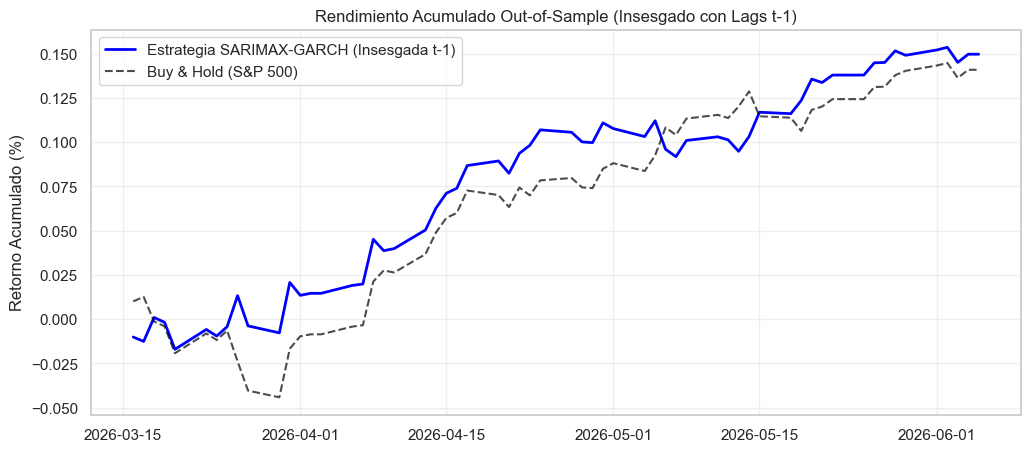

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Creación de variables exógenas retardadas (Lag 1) para eliminar Data Leakage
exog_vars = ['Yield10Y_change', 'DXYR', 'VIX_change']
exog_lags = [f"{var}_lag" for var in exog_vars]

# Aplicamos shift(1) a las variables exógenas
for var, lag_var in zip(exog_vars, exog_lags):
    if df[var].dtype == 'object':
        df[var] = df[var].astype(str).str.replace(',', '')
    df[lag_var] = pd.to_numeric(df[var], errors='coerce').shift(1)

cols_to_fix = ['SP500_Close', 'SP500R'] + exog_lags

for col in ['SP500_Close', 'SP500R']:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Eliminamos los NaN generados por la primera observación del shift(1)
df_c = df.dropna(subset=cols_to_fix).copy()

# 2. Configuración del Walk-Forward Insesgado
test_days = 60
n_obs = len(df_c)

actual_prices, pred_prices_model, pred_prices_rw = [], [], []
actual_returns, pred_returns, signals = [], [], []
dates = []

print(f"Ejecutando Walk-Forward Backtest Insesgado con Lags t-1 ({test_days} días fuera de muestra)...")

for i in range(n_obs - test_days, n_obs):
    train_set = df_c.iloc[:i]
    test_row = df_c.iloc[i]
    
    # Entrenamiento usando exclusivamente exógenas retardadas (t-1)
    mod_sarima = SARIMAX(train_set['SP500R'], exog=train_set[exog_lags], order=(1,0,1), trend='c').fit(disp=False)
    
    # La exógena conocida en t-1 para predecir t ya está registrada en test_row[exog_lags]
    exog_next = pd.DataFrame(test_row[exog_lags].astype(float)).T
    
    r_pred = float(mod_sarima.forecast(steps=1, exog=exog_next).iloc[0])
    p_last = float(train_set['SP500_Close'].iloc[-1])
    p_actual = float(test_row['SP500_Close'])
    r_actual = float(test_row['SP500R'])
    
    p_pred_model = p_last * np.exp(r_pred)
    p_pred_rw = p_last
    
    dates.append(df_c.index[i])
    actual_prices.append(p_actual)
    pred_prices_model.append(p_pred_model)
    pred_prices_rw.append(p_pred_rw)
    actual_returns.append(r_actual)
    pred_returns.append(r_pred)
    signals.append(float(np.sign(r_pred)))

# 3. DataFrame de resultados insesgados
df_eval = pd.DataFrame({
    'Precio_Real': np.array(actual_prices, dtype=float),
    'Pred_Model': np.array(pred_prices_model, dtype=float),
    'Pred_RW': np.array(pred_prices_rw, dtype=float),
    'Retorno_Real': np.array(actual_returns, dtype=float),
    'Retorno_Pred': np.array(pred_returns, dtype=float),
    'Signal': np.array(signals, dtype=float)
}, index=dates)

# 4. Cálculo de Métricas Insesgadas
mae_model = float(np.mean(np.abs(df_eval['Precio_Real'] - df_eval['Pred_Model'])))
mae_rw = float(np.mean(np.abs(df_eval['Precio_Real'] - df_eval['Pred_RW'])))
hit_rate = float(np.mean(np.sign(df_eval['Retorno_Pred']) == np.sign(df_eval['Retorno_Real'])))

df_eval['Retorno_Estrategia'] = df_eval['Signal'] * df_eval['Retorno_Real']
retorno_acum_modelo = float(np.prod(1 + df_eval['Retorno_Estrategia']) - 1)
retorno_acum_bh = float(np.prod(1 + df_eval['Retorno_Real']) - 1)

# --- REPORTE DE VALIDACIÓN INSESGADO ---
print("=" * 65)
print("   REPORTE DE VALIDACIÓN OUT-OF-SAMPLE INSESGADO (LAGS t-1)")
print("=" * 65)
print(f"Período Evaluado : {test_days} días hábiles")
print("-" * 65)
print(f"MAE Modelo SARIMAX(1,0,1) : ${mae_model:,.2f}")
print(f"MAE Random Walk (Baseline): ${mae_rw:,.2f}")
print(f"Diferencia Relativa (MAE) : {((mae_model - mae_rw) / mae_rw):+.2%}")
print("-" * 65)
print(f"Hit-Rate Direccional     : {hit_rate:.2%} (Acierto de signo real)")
print("=" * 65 + "\n")

print("=" * 65)
print("   RENDIMIENTO DE LA ESTRATEGIA INSESGADA (60 DÍAS)")
print("=" * 65)
print(f"Retorno Acumulado Estrategia (Long/Short) : {retorno_acum_modelo:+.2%}")
print(f"Retorno Acumulado Buy & Hold (Mercado)   : {retorno_acum_bh:+.2%}")
print(f"Alpha Generado (Excess Return)           : {(retorno_acum_modelo - retorno_acum_bh):+.2%}")
print("=" * 65)

# --- GRÁFICO DE RENDIMIENTO INSESGADO ---
plt.figure(figsize=(12, 5))
plt.plot(df_eval.index, (1 + df_eval['Retorno_Estrategia']).cumprod() - 1, label='Estrategia SARIMAX-GARCH (Insesgada t-1)', color='blue', lw=2)
plt.plot(df_eval.index, (1 + df_eval['Retorno_Real']).cumprod() - 1, label='Buy & Hold (S&P 500)', color='black', ls='--', alpha=0.7)
plt.title('Rendimiento Acumulado Out-of-Sample (Insesgado con Lags t-1)')
plt.ylabel('Retorno Acumulado (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Methodological Addendum

*This project has been changed throught time to develop and improve the model. I have included all these changes in the project, so you can see the model-building method I use and the steps I follow.*

*There are also changes and steps that depend entirely on Grtel but are not significant enough to warrant an extended explanation (such as testing the (p, q) values in the model).*

*This project is also updatable. You would simply need to change the date code, and the entire code would update from that day forward.*
